### 00 - Metricas importantes para Machine Learning Clássico

**Pré-requisitos**
    - Álgebra básica
    - Python básico
    - Noções iniciais de tabelas e gráficos



**Indice:**
1. Estatística descritiva e distribuição de dados
2. Amostragem, LLN e CLT
3. Inferência estatística, intervalos e testes
4. Correlação, causalidade e viés
5. Métricas de regressão e classificação


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style='whitegrid', context='notebook')

### 1 - População, Amostra e Variabilidade

**Definição formal:**
- População: conjunto total de interesse.
- Amostra: subconjunto usado para inferir sobre a população.
- Parâmetro: quantidade da população (ex.: média verdadeira).
- Estatística: estimativa calculada da amostra.

**Intuição:** modelos de ML quase sempre treinam em amostra e generalizam para população.

**Analogia prática:** medir pressão de toda cidade é inviável; mede-se um grupo representativo.

In [2]:
n = 10000
populacao = np.random.normal(loc=70, scale=12, size=n)
amostra = np.random.choice(populacao, size=100, replace=False)

df_raw = pd.DataFrame({'peso_populacao': populacao})
df_clean = pd.DataFrame({'peso_amostra': amostra})

print('Média população:', df_raw['peso_populacao'].mean())
print('Média amostra:', df_clean['peso_amostra'].mean())
print('Diferença absoluta:', abs(df_raw['peso_populacao'].mean() - df_clean['peso_amostra'].mean()))

Média população: 69.97436819957888
Média amostra: 71.40145498419625
Diferença absoluta: 1.427086784617373


### 2 - Por Baixo dos Panos: Distribuições e Suficiência Estatística

No ML clássico, muitas hipóteses sobre erro e ruído dependem de distribuição:
- Regressão linear: erros aproximadamente normais facilitam inferência de coeficientes.
- Classificação probabilística: modela-se distribuição condicional das classes.

Distribuição empírica é uma aproximação computacional da distribuição real. O histograma é uma discretização com perda de informação (trade-off resolução vs ruído).

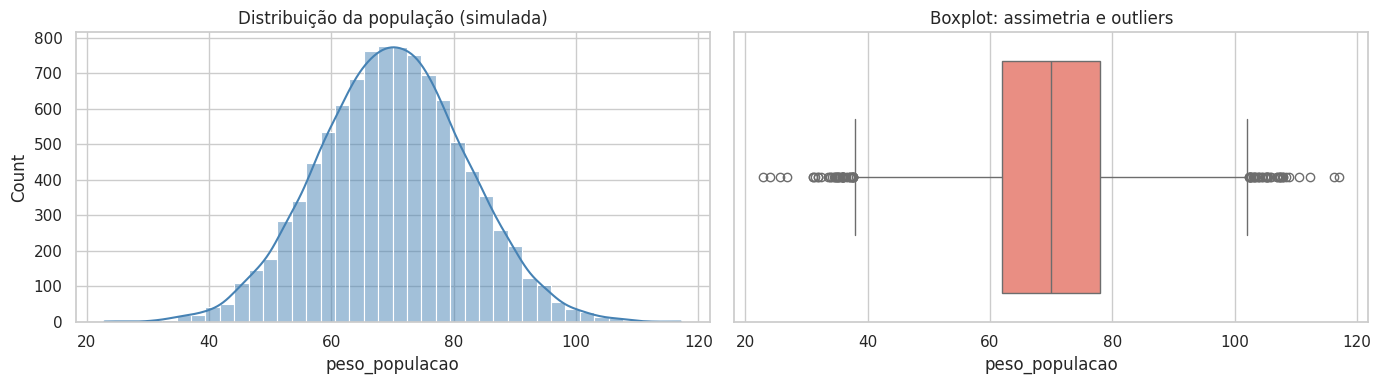

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_raw['peso_populacao'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da população (simulada)')

sns.boxplot(x=df_raw['peso_populacao'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot: assimetria e outliers')

plt.tight_layout()


### 3 - Demonstração Incremental: Lei dos Grandes Números (LLN)

A LLN explica por que a média amostral converge para a média populacional quando o tamanho da amostra cresce. Isso justifica o comportamento de estabilização de métricas em validação cruzada com mais dados.

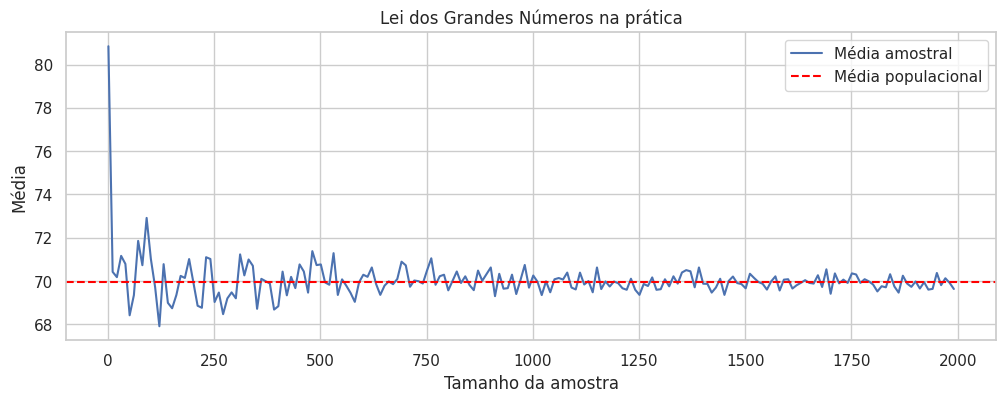

In [4]:
medias = []
tamanhos = np.arange(1, 2001, 10)
for t in tamanhos:
    medias.append(np.random.choice(populacao, size=t, replace=False).mean())

plt.figure(figsize=(12, 4))
plt.plot(tamanhos, medias, label='Média amostral')
plt.axhline(populacao.mean(), color='red', linestyle='--', label='Média populacional')
plt.title('Lei dos Grandes Números na prática')
plt.xlabel('Tamanho da amostra')
plt.ylabel('Média')
plt.legend()
plt.show()


### 4 - Por Baixo dos Panos: Teorema Central do Limite (CLT)

Mesmo quando os dados individuais não são normais, a distribuição da média amostral tende a normalidade para n suficientemente grande.

No ML, isso aparece em:
- Estimativas de métricas por folds
- Intervalos de confiança aproximados para desempenho
- Erros padrão de estimadores

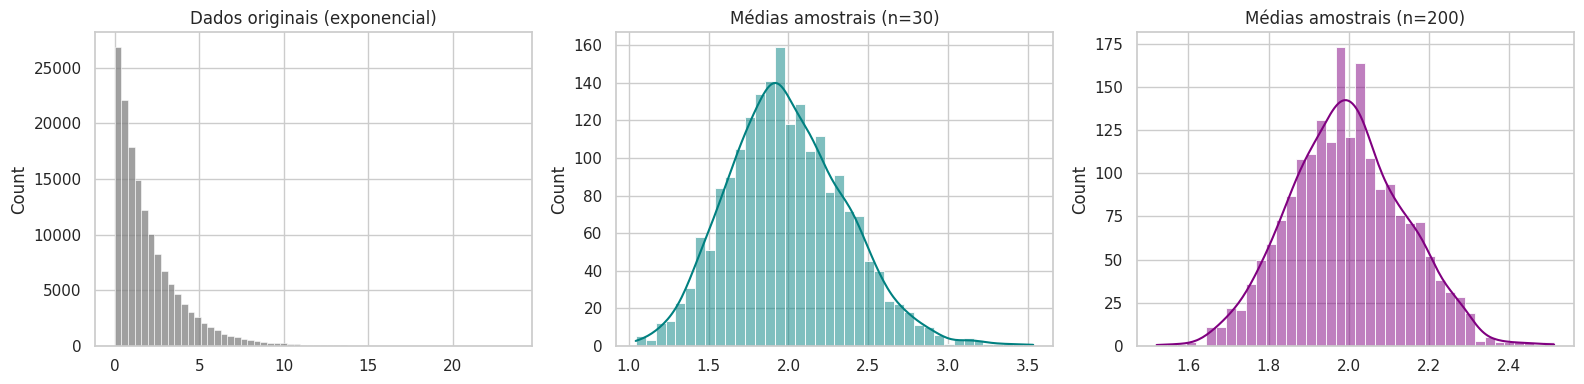

In [5]:
base_assimetrica = np.random.exponential(scale=2.0, size=150000)
medias_30 = [np.random.choice(base_assimetrica, size=30, replace=False).mean() for _ in range(2000)]
medias_200 = [np.random.choice(base_assimetrica, size=200, replace=False).mean() for _ in range(2000)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(base_assimetrica, bins=60, ax=axes[0], color='gray')
axes[0].set_title('Dados originais (exponencial)')

sns.histplot(medias_30, bins=40, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Médias amostrais (n=30)')

sns.histplot(medias_200, bins=40, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Médias amostrais (n=200)')

plt.tight_layout()


### 5 - Inferência: Intervalo de Confiança da Média

Intervalo de confiança (IC) não é "probabilidade do parâmetro" após ver os dados.
Interpretação correta: em repetidas amostragens, o procedimento cobre o parâmetro em ~95% dos casos (para IC 95%).

In [6]:
x = df_clean['peso_amostra'].to_numpy()
media = x.mean()
std = x.std(ddof=1)
n = len(x)
se = std / np.sqrt(n)

# Aproximação normal 95%: z = 1.96
ic_inf = media - 1.96 * se
ic_sup = media + 1.96 * se

print(f'Média amostral: {media:.4f}')
print(f'IC 95% aproximado: [{ic_inf:.4f}, {ic_sup:.4f}]')
print(f'Média populacional real (simulada): {populacao.mean():.4f}')


Média amostral: 71.4015
IC 95% aproximado: [68.8834, 73.9195]
Média populacional real (simulada): 69.9744


### 6 - Teste de Hipótese e Erros Tipo I/II

- H0: hipótese nula
- H1: hipótese alternativa
- p-valor: probabilidade de observar estatística tão extrema quanto a observada, assumindo H0 verdadeira.

No contexto de ML, decisões de feature engineering e comparações de modelo podem ser formalizadas com testes apropriados.

In [7]:
# Teste z aproximado para H0: média = 70
mu0 = 70
z = (media - mu0) / se

# Cálculo de p-valor bicaudal via aproximação normal usando erro complementar
from math import erf, sqrt

def normal_cdf(v):
    return 0.5 * (1 + erf(v / sqrt(2)))

p_valor = 2 * (1 - normal_cdf(abs(z)))
print(f'Estatística z: {z:.4f}')
print(f'p-valor bicaudal: {p_valor:.6f}')


Estatística z: 1.0908
p-valor bicaudal: 0.275339


### 7 - Correlação vs Causalidade

Correlação mede associação linear; não identifica direção causal nem confusão.
Em ML preditivo, alta correlação pode ajudar a prever, mas não implica mecanismo causal.

          X         Y
X  1.000000 -0.940101
Y -0.940101  1.000000


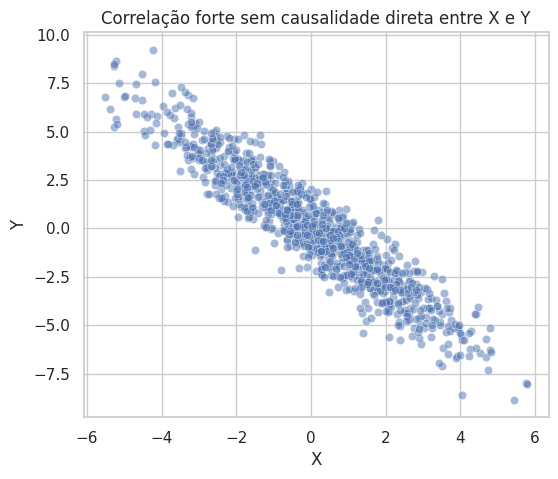

In [8]:
n = 5000
confundidor = np.random.normal(0, 1, n)
X = 2 * confundidor + np.random.normal(0, 0.6, n)
Y = (-3) * confundidor + np.random.normal(0, 0.6, n)

df_corr = pd.DataFrame({'X': X, 'Y': Y, 'confundidor': confundidor})
print(df_corr[['X', 'Y']].corr())

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_corr.sample(1000, random_state=42), x='X', y='Y', alpha=0.5)
plt.title('Correlação forte sem causalidade direta entre X e Y')
plt.show()


### 8 - Viés, Variância e Erro de Generalização

Erro total pode ser decomposto (didaticamente) em:
- Viés: simplificação excessiva do modelo
- Variância: sensibilidade ao ruído da amostra
- Ruído irreducível

Trade-off central de ML clássico: reduzir viés aumenta variância e vice-versa.

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
X = np.linspace(-3, 3, 300)
y = np.sin(X) + rng.normal(0, 0.2, 300)

X = X.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

graus = [1, 3, 12, 20, 100]
for g in graus:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=g, include_bias=False)),
        ('lr', LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f'Grau {g} | RMSE treino: {root_mean_squared_error(y_train, y_pred_train):.4f} | RMSE teste: {root_mean_squared_error(y_test, y_pred_test):.4f}')


Grau 1 | RMSE treino: 0.4499 | RMSE teste: 0.4736
Grau 3 | RMSE treino: 0.1939 | RMSE teste: 0.2014
Grau 12 | RMSE treino: 0.1830 | RMSE teste: 0.1877
Grau 20 | RMSE treino: 0.1821 | RMSE teste: 0.1869
Grau 100 | RMSE treino: 0.7307 | RMSE teste: 0.7652


### 9 - Métricas Base: Regressão e Classificação

Escolha de métrica é decisão de negócio:
- Regressão: MAE, RMSE, R²
- Classificação: precision, recall, F1, ROC-AUC, PR-AUC

In [10]:
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, average_precision_score
)

# Regressão
y_true_reg = np.array([3.0, 2.5, 4.0, 5.0, 4.5])
y_pred_reg = np.array([2.8, 2.4, 4.2, 4.4, 4.9])
print('MAE:', mean_absolute_error(y_true_reg, y_pred_reg))
print('RMSE:', root_mean_squared_error(y_true_reg, y_pred_reg))
print('R2:', r2_score(y_true_reg, y_pred_reg))

# Classificação desbalanceada
y_true_clf = np.array([0, 0, 0, 0, 1, 1, 1])
y_pred_clf = np.array([0, 0, 0, 1, 1, 0, 1])
y_score = np.array([0.05, 0.10, 0.20, 0.70, 0.85, 0.40, 0.90])

print('Precision:', precision_score(y_true_clf, y_pred_clf))
print('Recall:', recall_score(y_true_clf, y_pred_clf))
print('F1:', f1_score(y_true_clf, y_pred_clf))
print('PR-AUC:', average_precision_score(y_true_clf, y_score))


MAE: 0.3000000000000001
RMSE: 0.3492849839314596
R2: 0.858139534883721
Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1: 0.6666666666666666
PR-AUC: 0.9166666666666665


### 10 - Erros Comuns e Como Depurar

- Confundir média de amostra com verdade populacional
- Usar teste paramétrico sem verificar premissas
- Escolher métrica inadequada para desbalanceamento
- Interpretar correlação como causalidade

**Checklist de depuração estatística**
1. Verificar qualidade dos dados e outliers
2. Conferir distribuição e escala
3. Validar suposições do método
4. Reportar incerteza (intervalos, variabilidade)
